In [ ]:
import torch
import math
import matplotlib.pyplot as plt
from copy import deepcopy
from einops import rearrange, repeat
from torch import nn
from torch.nn import functional as F
from torch.optim import Adam
from tqdm import trange
from IPython.display import clear_output

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
torch.set_default_device(device)

# Primitives

In [ ]:
def sample_x_0(size, **kwargs):
  # [-1.5, -0.5, +0.5, +1.5]
  return torch.randint(0, 4, size, dtype=torch.float, **kwargs) - 1.5 + torch.randn(size) * 0.05

def sample_x_T(size, **kwargs):
  return torch.randn(size, **kwargs)

def sample_t_src(size, nfe):
  # [0.25, 0.5, 0.75, 1.0]
  return torch.randint(1, nfe + 1, size, dtype=torch.float) / nfe

def sample_t_tgt(t_src, nfe):
  return t_src - (1 / nfe)

def diffuse(x_0, x_T, t):
  return x_0 * (1 - t) + x_T * (t)

# Networks

In [ ]:
def sinusoidal_encode(
    value: torch.Tensor,
    dim: int,
    downscale_freq_shift: float = 1,
    max_period: int = 10000,
):
    assert len(value.shape) == 1, "value should be a 1d-array"
    assert dim % 2 == 0, "dim must be divisible by 2 for sin and cos"

    value = value * 100 # scale -1 ~ +1 to -100 ~ +100 for better encoding.

    half_dim = dim // 2
    exponent = -math.log(max_period) * torch.arange(
        0, half_dim, dtype=torch.float32, device=value.device
    )
    exponent = exponent / (half_dim - downscale_freq_shift)

    emb = torch.exp(exponent)
    emb = value[:, None].float() * emb[None, :]
    emb = torch.cat([torch.sin(emb), torch.cos(emb)], dim=-1)
    return emb

In [ ]:
class Network(nn.Module):
  def __init__(self, in_channels, dim=1024):
    super().__init__()
    self.net = nn.Sequential(
        nn.Linear(in_channels * 64, dim),
        nn.SiLU(),
        nn.Linear(dim, dim),
        nn.SiLU(),
        nn.Linear(dim, dim),
        nn.SiLU(),
        nn.Linear(dim, dim),
        nn.SiLU(),
        nn.Linear(dim, 1),
    )

  def forward(self, *args):
    x = [sinusoidal_encode(arg, 64) for arg in args]
    x = torch.cat(x, dim=-1)
    x = self.net(x)
    x = x.view(-1)
    return x


class Generator(Network):
  def __init__(self):
    super().__init__(in_channels=3)

  def forward(self, x_src, t_src, t_tgt):
    return super().forward(x_src, t_src, t_tgt)


class Discriminator(Network):
  def __init__(self):
    super().__init__(in_channels=2)

  def forward(self, x_tgt, t_tgt):
    return super().forward(x_tgt, t_tgt)

In [ ]:
@torch.no_grad()
def visualize(nfe, show_flow_background=True):
  if show_flow_background:
    # Draw probability flow
    samples = 50000
    timesteps = 500
    t = torch.linspace(0, 1, timesteps)
    x_0 = sample_x_0([timesteps, samples])
    x_T = sample_x_T([timesteps, samples])
    x_t = diffuse(x_0, x_T, t.unsqueeze(-1))

    # Draw 2d histogram.
    plt.hist2d(
        x=repeat(t, "t -> (t v)", v=samples).cpu().numpy(),
        y=rearrange(x_t, "t v -> (t v)").cpu().numpy(),
        cmap='viridis',
        bins=(timesteps, 500),
        range=((0, 1), (-2.2, 2.2)),
        cmax=500,
    )
  else:
    plt.gca().set_facecolor((62/256, 7/256, 81/256))

  # Draw trajectory
  samples=20
  ts = torch.linspace(1.0, 0.0, nfe + 1).view(-1, 1).repeat(1, samples)
  xs = [torch.linspace(-2, 2, samples)]
  for t_src, t_tgt in zip(ts[:-1], ts[1:]):
    xs.append(ema(xs[-1], t_src, t_tgt))
  xs = torch.stack(xs)

  for t, x in zip(ts.T, xs.T):
    plt.plot(t.cpu().numpy(), x.cpu().numpy(), color="white")

  # Draw step divider
  if nfe <= 10:
    for t in ts.tolist()[1:-1]:
      plt.plot([t, t], [100, -100], color="black", linewidth=1.0)

  plt.xticks([])
  plt.yticks([])
  plt.xlim(0, 1)
  plt.subplots_adjust(left=0, right=1, top=1, bottom=0)
  plt.gcf().set_size_inches(3, 2)
  plt.savefig('my_plot.png', dpi=300, bbox_inches='tight', pad_inches=0)
  plt.show()

# Training

In [ ]:
def train(
    gen,
    dis,
    ema,
    gen_optimizer,
    dis_optimizer,
    *,
    batch_size,
    total_steps,
    ot_scale,
    gp_scale = 0.01,
    gp_eps = 0.01,
    cp_scale = 0.01,
    visualize_interval = 200,
    ema_decay = 0.99,
    nfe = 1,
    show_flow_background = True
):
  for step in trange(total_steps):

    if step % visualize_interval == 0:
      clear_output(wait=True)
      visualize(nfe, show_flow_background)

    dis.requires_grad_(step % 2 == 0)
    gen.requires_grad_(step % 2 == 1)

    x_0 = sample_x_0([batch_size])
    x_T = sample_x_T([batch_size])

    t_src = sample_t_src([batch_size], nfe)
    t_tgt = sample_t_tgt(t_src, nfe)

    x_src_real = diffuse(x_0, x_T, t_src)
    x_tgt_real = diffuse(x_0, x_T, t_tgt)
    x_tgt_fake = gen(x_src_real, t_src, t_tgt)

    logits_real = dis(x_tgt_real, t_tgt)
    logits_fake = dis(x_tgt_fake, t_tgt)

    w = (t_src - t_tgt).abs().clamp_min(0.001)

    if step % 2 == 0:
      # Discriminator step.
      logits_real_r1 = dis(x_tgt_real + gp_eps * torch.randn_like(x_tgt_real), t_tgt)
      logits_fake_r2 = dis(x_tgt_fake + gp_eps * torch.randn_like(x_tgt_fake), t_tgt)

      dis_loss = (
          F.softplus(-(logits_real - logits_fake)).mean() +                     # Relativistic adversarial loss.
          (logits_real - logits_real_r1).square().mul(gp_scale * w / gp_eps ** 2).mean() + # Approximated R1 regularization.
          (logits_fake - logits_fake_r2).square().mul(gp_scale * w / gp_eps ** 2).mean() + # Approximated R2 regularization.
          (logits_real + logits_fake).square().mul(cp_scale).mean()             # Logit centering regularization.
      )
      dis_loss.backward()
      dis_optimizer.step()
      dis_optimizer.zero_grad()

    else:
      # Generator step.
      gen_loss = (
          F.softplus(-(logits_fake - logits_real)).mean() +                     # Relativistic adversarial loss.
          (x_tgt_fake - x_src_real).square().mul(ot_scale / w).mean()           # Optimal transport loss.
      )
      gen_loss.backward()
      gen_optimizer.step()
      gen_optimizer.zero_grad()

      # Update ema.
      for p_gen, p_ema in zip(gen.parameters(), ema.parameters()):
          p_ema.data.lerp_(p_gen.data, 1 - ema_decay)

In [ ]:
gen = Generator()
dis = Discriminator()
ema = deepcopy(gen)
gen_optimizer = Adam(gen.parameters(), lr=1e-4, betas=(0.0, 0.9))
dis_optimizer = Adam(dis.parameters(), lr=1e-4, betas=(0.0, 0.9))

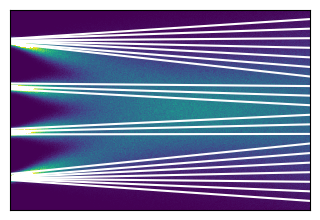

100%|██████████| 10000/10000 [06:19<00:00, 26.33it/s]


In [ ]:
train(
    gen, dis, ema, gen_optimizer, dis_optimizer,
    batch_size=1024,
    total_steps=10000,
    ot_scale=0.05,
    nfe=1,
    show_flow_background=True,
)